In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
import PIL
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader



In [24]:
train_data_dir = '../sign_lang_recognition/data/sign_mnist_train.csv'
test_data_dir = '../sign_lang_recognition/data/sign_mnist_test.csv'

In [25]:
class SignLanguageMNIST(torch.utils.data.Dataset):
    def __init__(self, csv_file, label_map, transform=None):
        self.data = pd.read_csv(csv_file)
        self.labels = self.data['label'].map(label_map).values
        # If not account for missing 2 classes
        # self.labels = self.data['label'].values
        
        # 784 pixel columns, so 28x28 with 1 channel (grayscale)
        pixels = self.data.drop('label', axis=1).values
        self.images = pixels.reshape(-1, 28, 28, 1).astype(np.uint8)
        
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label
    
to_tensor = transforms.ToTensor()

train_df = pd.read_csv(train_data_dir)
label_map = {l:i for i,l in enumerate(sorted(train_df['label'].unique()))}

train_tensor = SignLanguageMNIST(csv_file=train_data_dir, label_map=label_map, transform=to_tensor)
test_tensor = SignLanguageMNIST(csv_file=test_data_dir, label_map=label_map, transform=to_tensor)

Verifying the number of classes given the description that there are no cases for 9=J or 25=Z because of gesture motions.

In [26]:
print("Number of unique labels in training set:", pd.Series(train_tensor.labels).nunique())
#print("The Classes not on here:", set(range(26)) - set(pd.Series(train_tensor.labels).unique()))
#print(pd.Series(train_tensor.labels).value_counts())

Number of unique labels in training set: 24


In [29]:
train_img = torch.stack([img for img, _ in train_tensor])

train_mean = train_img.view(1,-1).mean(dim=1)
train_std = train_img.view(1,-1).std(dim=1)

valid_img = torch.stack([img for img, _ in test_tensor])
valid_mean = valid_img.view(1,-1).mean(dim=1)
valid_std = valid_img.view(1,-1).std(dim=1)

# Reload the Datasets with the normalization transforms
transformed_train_tensor = SignLanguageMNIST(
    csv_file=train_data_dir, 
    label_map=label_map,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(train_mean, train_std)
    ])
)

transformed_test_tensor = SignLanguageMNIST(
    csv_file=test_data_dir, 
    label_map=label_map,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(valid_mean, valid_std)])
)

transformed_test_tensor_norm_w_train = SignLanguageMNIST(
    csv_file=test_data_dir, 
    label_map=label_map,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(train_mean, train_std)])
)

In [ ]:
train_loader = DataLoader(transformed_train_tensor, batch_size=64, shuffle=True)
test_loader = DataLoader(transformed_test_tensor, batch_size=64, shuffle=False)
test_loader_norm_w_train = DataLoader(transformed_test_tensor_norm_w_train, batch_size=64, shuffle=False)

In [ ]:
def train_model(n_epochs, model, optimizer, loss_fn, train_loader, val_loader):
    log_data = [] 
    
    for epoch in range(1, n_epochs + 1):
        model.train() 
        epoch_train_loss = 0.0
        train_correct, train_total = 0, 0
        for imgs, labels in train_loader:
            optimizer.zero_grad()
            preds = model(imgs)
            loss = loss_fn(preds, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            predicted = preds.argmax(dim=1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        model.eval() 
        epoch_val_loss = 0.0
        val_correct, val_total = 0, 0
        with torch.no_grad(): 
            for imgs, labels in val_loader: 
                preds = model(imgs)
                loss = loss_fn(preds, labels)
                epoch_val_loss += loss.item()
                predicted = preds.argmax(dim=1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        log_data.append({
            'epoch': epoch,
            'train_loss': epoch_train_loss / len(train_loader),
            'validation_loss': epoch_val_loss / len(val_loader),
            'train_accuracy': train_correct / train_total,
            'validation_accuracy': val_correct / val_total,
            'learning_rate': optimizer.param_groups[0]['lr']
        })
    return pd.DataFrame(log_data)

In [ ]:
mlp_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 24)
)

adam_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

In [30]:
mlp_log = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model, 
                      train_loader=train_loader, 
                      val_loader=test_loader)


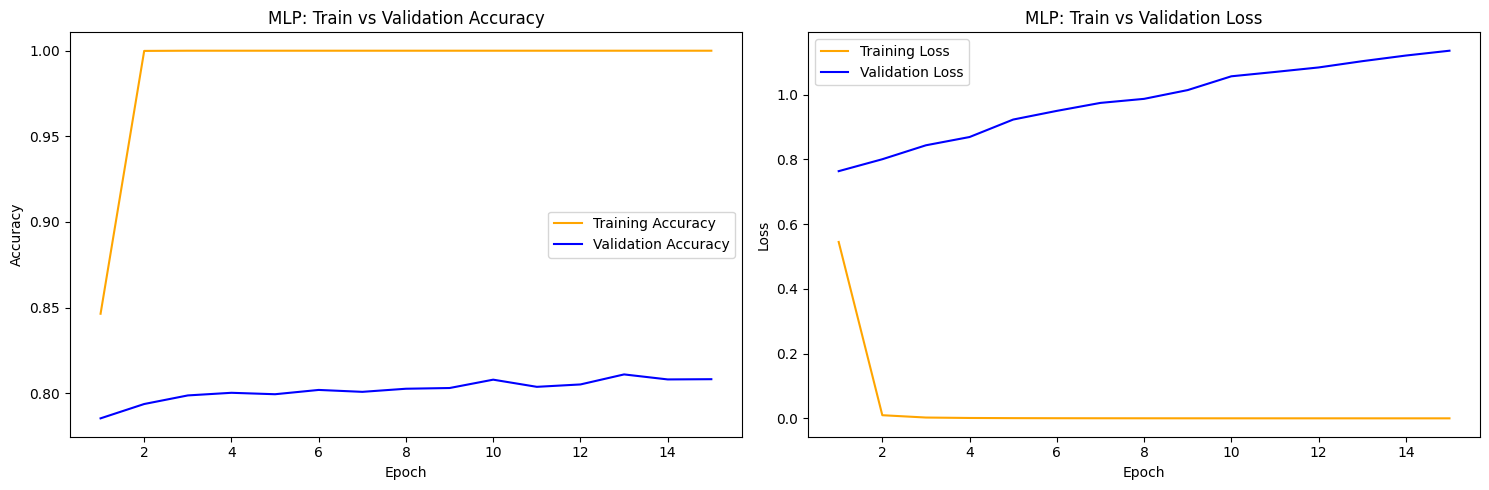

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(mlp_log['epoch'], mlp_log['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log['epoch'], mlp_log['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('MLP: Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log['epoch'], mlp_log['train_loss'], color='orange', label='Training Loss')
axes[1].plot(mlp_log['epoch'], mlp_log['validation_loss'], color='blue', label='Validation Loss')
axes[1].set_title('MLP: Train vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

To avoid data leakage, the test set must be normalized using the mean and standard deviation derived strictly from the training set. This ensures the model treats unseen data as it would in a real-world scenario. So trying an interation with the test data normalized using the train mean and standard deviation.

In [ ]:
mlp_log_2 = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model, 
                      train_loader=train_loader, 
                      val_loader=test_loader_norm_w_train)

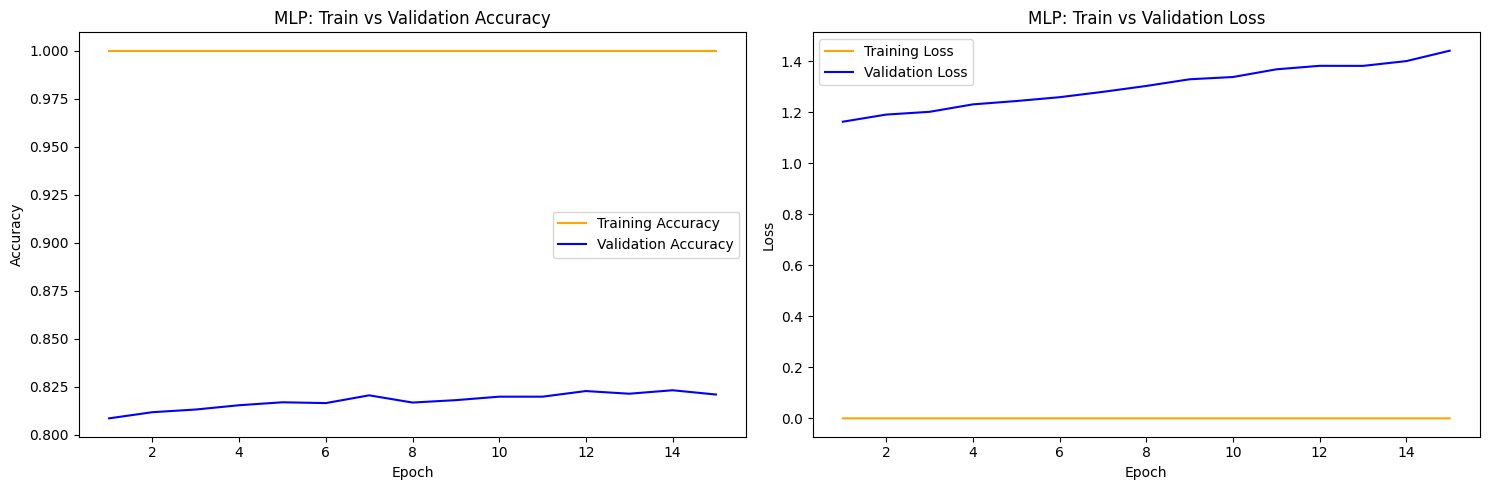

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(mlp_log_2['epoch'], mlp_log_2['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log_2['epoch'], mlp_log_2['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('MLP: Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log_2['epoch'], mlp_log_2['train_loss'], color='orange', label='Training Loss')
axes[1].plot(mlp_log_2['epoch'], mlp_log_2['validation_loss'], color='blue', label='Validation Loss')
axes[1].set_title('MLP: Train vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

What if we tried to increase the depth?

In [ ]:
mlp_model_deep = nn.Sequential(
    nn.Flatten(),                 
    nn.Linear(784, 400),
    nn.ReLU(),
    nn.Linear(400, 256),          
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 26) 
)

mlp_log_deep = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_deep, 
                      train_loader=train_loader, 
                      val_loader=test_loader_norm_w_train)

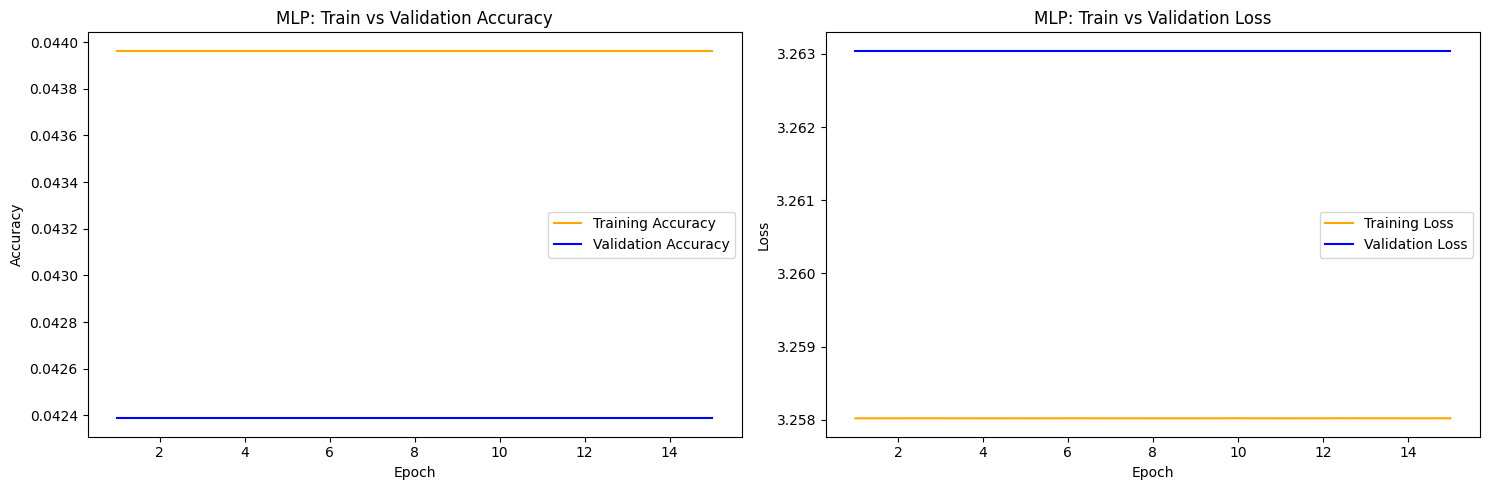

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(mlp_log_deep['epoch'], mlp_log_deep['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log_deep['epoch'], mlp_log_deep['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('MLP: Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log_deep['epoch'], mlp_log_deep['train_loss'], color='orange', label='Training Loss')
axes[1].plot(mlp_log_deep['epoch'], mlp_log_deep['validation_loss'], color='blue', label='Validation Loss')
axes[1].set_title('MLP: Train vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Based on the results from these two models, the training accuracy is approximately 1 while the testing accuracy is much lower at around 0.8, so there could be potential overfitting to the training data. 

Potential Remedy #1: Reducing the number of layers

In [ ]:
mlp_model_small = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 24)
)

mlp_log_small = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_small, 
                      train_loader=train_loader, 
                      val_loader=test_loader_norm_w_train)

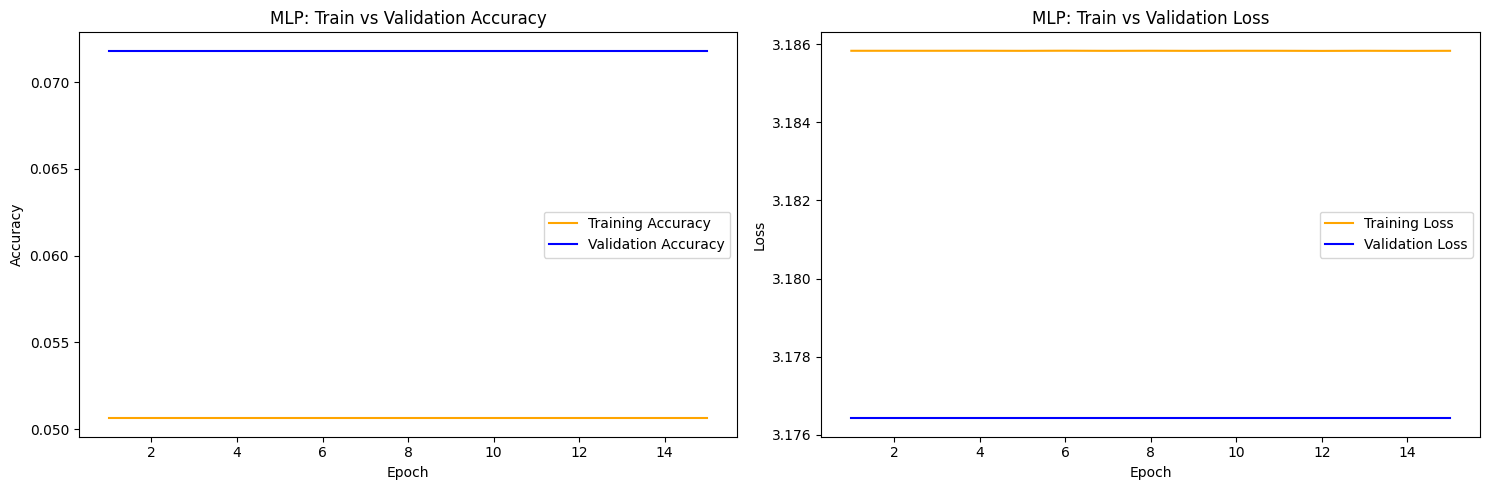

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(mlp_log_small['epoch'], mlp_log_small['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log_small['epoch'], mlp_log_small['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('MLP: Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log_small['epoch'], mlp_log_small['train_loss'], color='orange', label='Training Loss')
axes[1].plot(mlp_log_small['epoch'], mlp_log_small['validation_loss'], color='blue', label='Validation Loss')
axes[1].set_title('MLP: Train vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Potential Remedy #2: Dropout Layers

In [ ]:
mlp_model_dropout = nn.Sequential(
    nn.Flatten(),                 
    nn.Linear(784, 256),
    # p = 0.3, too much (both accuracies drop to 0.4)
    nn.Dropout(p=0.1),
    nn.Linear(256, 128),          
    nn.ReLU(),
    nn.Dropout(p=0.1),
    nn.Linear(128, 26)            
)

mlp_log_dropout = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_dropout, 
                      train_loader=train_loader, 
                      val_loader=test_loader_norm_w_train)

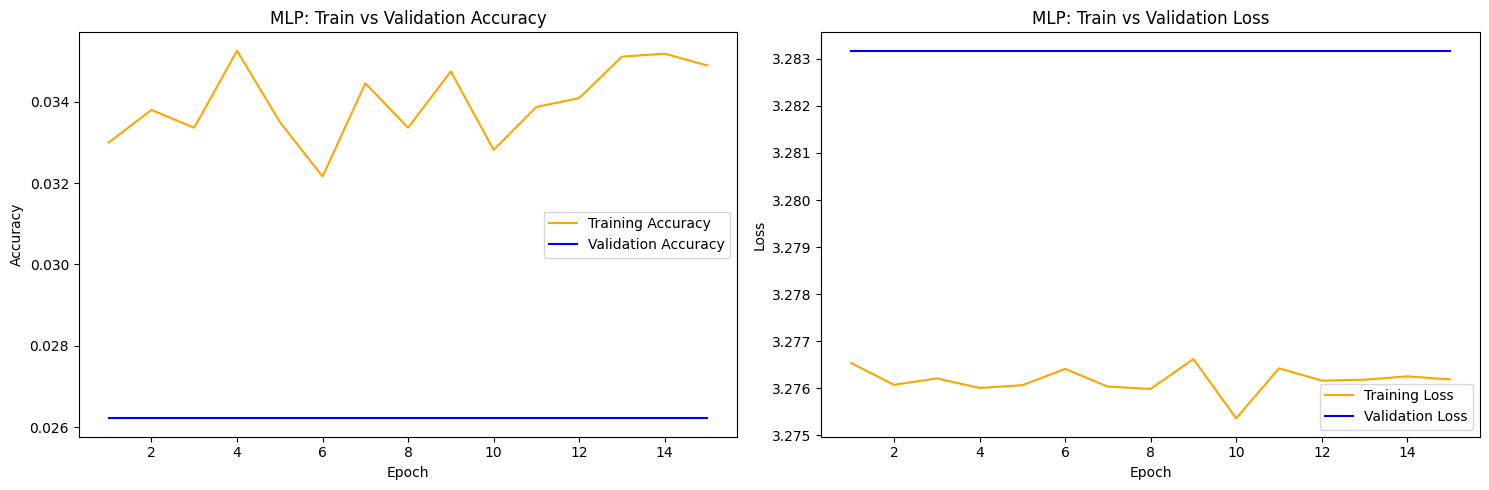

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(mlp_log_dropout['epoch'], mlp_log_dropout['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log_dropout['epoch'], mlp_log_dropout['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('MLP: Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log_dropout['epoch'], mlp_log_dropout['train_loss'], color='orange', label='Training Loss')
axes[1].plot(mlp_log_dropout['epoch'], mlp_log_dropout['validation_loss'], color='blue', label='Validation Loss')
axes[1].set_title('MLP: Train vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
p_values = [0.1, 0.2, 0.3, 0.4, 0.5]
grid_search_results = []

for p in p_values:
    current_model = nn.Sequential(
        nn.Flatten(),                 
        nn.Linear(784, 256),
        nn.ReLU(),
        nn.Dropout(p=p),
        nn.Linear(256, 128),          
        nn.ReLU(),
        nn.Dropout(p=p),
        nn.Linear(128, 26)            
    )
    
    log_df = train_model(n_epochs=5, 
                         model=current_model, 
                         optimizer=adam_optimizer,
                         loss_fn=nn.CrossEntropyLoss(),
                         train_loader=train_loader, 
                         val_loader=test_loader)
    
    final_train_acc = log_df['train_accuracy'].iloc[-1]
    final_val_acc = log_df['validation_accuracy'].iloc[-1]
    
    grid_search_results.append({
        'p_value': p,
        'final_train_accuracy': final_train_acc,
        'final_validation_accuracy': final_val_acc
    })

results_df = pd.DataFrame(grid_search_results)
best_results = results_df.sort_values(by='final_validation_accuracy', ascending=False)

print("\n=== Grid Search Results ===")
print(best_results)


=== Grid Search Results ===
   p_value  final_train_accuracy  final_validation_accuracy
4      0.5              0.043198                   0.070273
3      0.4              0.032781                   0.046709
1      0.2              0.044364                   0.024679
0      0.1              0.025351                   0.023564
2      0.3              0.038244                   0.022727


Although the first MLP model with 3 layers ($728 -> 256 -> 128 -> 24$) Observations suggest that while overfitting is a risk, the current depth is necessary to achieve the desired accuracy. To balance this, increasing the model's depth while implementing Dropout layers can capture complex data patterns while improving generalization. This approach allows the network to learn sophisticated features without becoming overly reliant on specific neurons, effectively regularizing the added complexity.

In [ ]:
mlp_model_deep_w_dropout = nn.Sequential(
    nn.Flatten(),                 
    nn.Linear(784, 400),
    nn.Dropout(p=0.1),
    nn.Linear(400, 256),          
    nn.ReLU(),
    nn.Dropout(p=0.1),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(p=0.1),
    nn.Linear(128, 26)           
)

mlp_log_deep_w_dropout  = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_deep_w_dropout, 
                      train_loader=train_loader, 
                      val_loader=test_loader_norm_w_train)

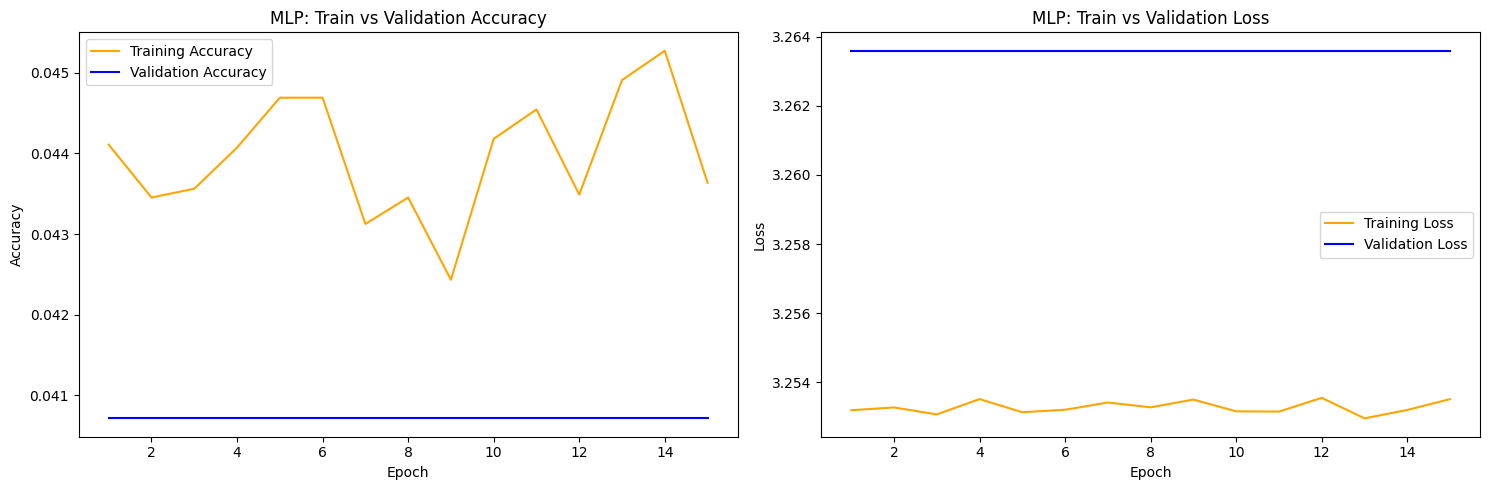

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(mlp_log_deep_w_dropout['epoch'], mlp_log_deep_w_dropout['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log_deep_w_dropout['epoch'], mlp_log_deep_w_dropout['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('MLP: Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log_deep_w_dropout['epoch'], mlp_log_deep_w_dropout['train_loss'], color='orange', label='Training Loss')
axes[1].plot(mlp_log_deep_w_dropout['epoch'], mlp_log_deep_w_dropout['validation_loss'], color='blue', label='Validation Loss')
axes[1].set_title('MLP: Train vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()